# Logistics Delivery Performance & Operational Analytics

**Exploratory analysis of delivery performance, delays, costs, and operational factors using Python.**

**Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn

## Project Overview

This project analyzes logistics delivery data to understand delivery performance, delays, costs, and operational factors affecting delivery efficiency.

## Objectives

- Evaluate overall delivery performance.
- Identify patterns associated with delivery delays.
- Analyze delivery time and delivery cost.
- Compare performance across vehicles, delivery modes, weather conditions, regions, and partners.
- Generate actionable business insights for improving logistics operations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/Delivery_Logistics.csv")

df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (25000, 15)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  str    
 2   package_type         25000 non-null  str    
 3   vehicle_type         25000 non-null  str    
 4   delivery_mode        25000 non-null  str    
 5   region               25000 non-null  str    
 6   weather_condition    25000 non-null  str    
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  str    
 10  expected_time_hours  25000 non-null  str    
 11  delayed              25000 non-null  str    
 12  delivery_status      25000 non-null  str    
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), str(10)
memory usage: 

The dataset contains delivery-level operational information including delivery characteristics, time, cost, vehicle, weather, region, and performance indicators.

## Dataset Overview

The dataset contains information related to delivery operations, including:

- Delivery characteristics
- Operational conditions
- Delivery time and expected time
- Delay status
- Delivery cost
- Customer/delivery rating

In [45]:
df.describe(include="all")

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
count,25000.000000,25000,25000,25000,25000,25000,25000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000,25000.000000,25000.000000
unique,NaN,9,9,6,4,5,6,NaN,NaN,NaN,9,NaN,3,NaN,NaN
top,NaN,xpressbees,fragile items,ev bike,two day,west,foggy,NaN,NaN,NaN,1970-01-01 00:00:00.000000016,NaN,delivered,NaN,NaN
freq,NaN,2826,2848,4218,6302,5095,4219,NaN,NaN,NaN,6302,NaN,18331,NaN,NaN
mean,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,150.390436,25.145898,6.248040,NaN,0.266760,NaN,3.666000,864.944579
std,7212.732314,NaN,NaN,NaN,NaN,NaN,NaN,86.409745,14.368663,3.140935,NaN,0.442275,NaN,1.149964,435.712593
min,250.990000,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,0.670000,0.000000,NaN,0.000000,NaN,1.000000,95.667400
25%,6250.750000,NaN,NaN,NaN,NaN,NaN,NaN,75.900000,12.680000,4.000000,NaN,0.000000,NaN,3.000000,490.800000
50%,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,151.000000,25.145000,6.000000,NaN,0.000000,NaN,4.000000,867.535000
75%,18750.250000,NaN,NaN,NaN,NaN,NaN,NaN,224.900000,37.660000,8.000000,NaN,1.000000,NaN,5.000000,1237.910000


In [46]:
df.isnull().sum()

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

In [47]:
df.columns.tolist()

['delivery_id',
 'delivery_partner',
 'package_type',
 'vehicle_type',
 'delivery_mode',
 'region',
 'weather_condition',
 'distance_km',
 'package_weight_kg',
 'delivery_time_hours',
 'expected_time_hours',
 'delayed',
 'delivery_status',
 'delivery_rating',
 'delivery_cost']

In [48]:
df.dtypes

delivery_id            float64
delivery_partner           str
package_type               str
vehicle_type               str
delivery_mode              str
region                     str
weather_condition          str
distance_km            float64
package_weight_kg      float64
delivery_time_hours    float64
expected_time_hours        str
delayed                  int64
delivery_status            str
delivery_rating          int64
delivery_cost          float64
dtype: object

In [49]:
df.nunique()

delivery_id            24502
delivery_partner           9
package_type               9
vehicle_type               6
delivery_mode              4
region                     5
weather_condition          6
distance_km             2935
package_weight_kg       4853
delivery_time_hours       20
expected_time_hours        9
delayed                    2
delivery_status            3
delivery_rating            5
delivery_cost          22670
dtype: int64

In [50]:
# Missing values
df.isnull().sum()

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

In [51]:
# Duplicate records
df.duplicated().sum()

np.int64(0)

In [52]:
# Unique values in categorical columns
categorical_cols = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "delivery_status"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


delivery_partner:
<StringArray>
[       'delhivery',       'xpressbees',        'shadowfax',
              'dhl', 'amazon logistics',        'blue dart',
            'fedex',     'ecom express',            'ekart']
Length: 9, dtype: str

package_type:
<StringArray>
['automobile parts',        'cosmetics',        'groceries',
      'electronics',         'clothing',        'documents',
    'fragile items',         'pharmacy',        'furniture']
Length: 9, dtype: str

vehicle_type:
<StringArray>
['bike', 'ev van', 'truck', 'van', 'ev bike', 'scooter']
Length: 6, dtype: str

delivery_mode:
<StringArray>
['same day', 'express', 'two day', 'standard']
Length: 4, dtype: str

region:
<StringArray>
['west', 'central', 'east', 'north', 'south']
Length: 5, dtype: str

weather_condition:
<StringArray>
['clear', 'cold', 'rainy', 'foggy', 'hot', 'stormy']
Length: 6, dtype: str

delivery_status:
<StringArray>
['delivered', 'delayed', 'failed']
Length: 3, dtype: str


In [53]:
print(df["delivery_time_hours"].head(10))
print(df["delivery_time_hours"].dtype)

print(df["delayed"].head(10))
print(df["delayed"].dtype)

print(df["delayed"].value_counts(dropna=False))

0     8.0
1     2.0
2    10.0
3     6.0
4     9.0
5     4.0
6     6.0
7     4.0
8     5.0
9     3.0
Name: delivery_time_hours, dtype: float64
float64
0    0
1    0
2    0
3    0
4    0
5    1
6    0
7    0
8    0
9    0
Name: delayed, dtype: int64
int64
delayed
0    18331
1     6669
Name: count, dtype: int64


In [54]:
original_df = pd.read_csv("../data/Delivery_Logistics.csv")

print(original_df["delivery_time_hours"].head(10))
print(original_df["delivery_time_hours"].dtype)

print(original_df["delayed"].head(10))
print(original_df["delayed"].dtype)

0    1970-01-01 00:00:00.000000008
1    1970-01-01 00:00:00.000000002
2    1970-01-01 00:00:00.000000010
3    1970-01-01 00:00:00.000000006
4    1970-01-01 00:00:00.000000009
5    1970-01-01 00:00:00.000000004
6    1970-01-01 00:00:00.000000006
7    1970-01-01 00:00:00.000000004
8    1970-01-01 00:00:00.000000005
9    1970-01-01 00:00:00.000000003
Name: delivery_time_hours, dtype: str
str
0     no
1     no
2     no
3     no
4     no
5    yes
6     no
7     no
8     no
9     no
Name: delayed, dtype: str
str


In [55]:
df = pd.read_csv("../data/Delivery_Logistics.csv")

df["delivery_time_hours"] = df["delivery_time_hours"].astype(str).str.extract(r'(\d+)')[0]
df["delivery_time_hours"] = pd.to_numeric(df["delivery_time_hours"], errors="coerce")

df["delayed"] = df["delayed"].str.lower().map({
    "yes": 1,
    "no": 0
})

print(df["delivery_time_hours"].head())
print(df["delayed"].head())

0    1970
1    1970
2    1970
3    1970
4    1970
Name: delivery_time_hours, dtype: int64
0    0
1    0
2    0
3    0
4    0
Name: delayed, dtype: int64


Insight: Time variance measures the difference between actual and expected delivery time, helping identify deviations from planned performance.

In [59]:
print(df["delivery_time_hours"].head(20).tolist())
print(df["delivery_time_hours"].dtype)

[1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970]
int64


In [60]:
# Restore delivery time from the original dataset
df["delivery_time_hours"] = original_df["delivery_time_hours"]

print(df["delivery_time_hours"].head(20))
print(df["delivery_time_hours"].dtype)

0     1970-01-01 00:00:00.000000008
1     1970-01-01 00:00:00.000000002
2     1970-01-01 00:00:00.000000010
3     1970-01-01 00:00:00.000000006
4     1970-01-01 00:00:00.000000009
5     1970-01-01 00:00:00.000000004
6     1970-01-01 00:00:00.000000006
7     1970-01-01 00:00:00.000000004
8     1970-01-01 00:00:00.000000005
9     1970-01-01 00:00:00.000000003
10    1970-01-01 00:00:00.000000005
11    1970-01-01 00:00:00.000000003
12    1970-01-01 00:00:00.000000008
13    1970-01-01 00:00:00.000000006
14    1970-01-01 00:00:00.000000012
15    1970-01-01 00:00:00.000000008
16    1970-01-01 00:00:00.000000010
17    1970-01-01 00:00:00.000000011
18    1970-01-01 00:00:00.000000004
19    1970-01-01 00:00:00.000000007
Name: delivery_time_hours, dtype: str
str


In [57]:
print("Total Rows:", len(df))
print("Unique Delivery IDs:", df["delivery_id"].nunique())
print("Duplicate Delivery IDs:", df["delivery_id"].duplicated().sum())

Total Rows: 25000
Unique Delivery IDs: 24502
Duplicate Delivery IDs: 498


## Key Performance Indicators (KPIs)

In [62]:
# KPI 1: Average Delivery Time
avg_delivery_time = df["delivery_time_hours"].mean()

# KPI 2: Average Delivery Cost
avg_delivery_cost = df["delivery_cost"].mean()

# KPI 3: On-Time Delivery Rate
on_time_rate = (df["delayed"] == 0).mean() * 100

# KPI 4: Delivery Delay Rate
delay_rate = (df["delayed"] == 1).mean() * 100

# KPI 5: Shipment Volume
shipment_volume = len(df)

print(f"Average Delivery Time: {avg_delivery_time:.2f} hours")
print(f"Average Delivery Cost: {avg_delivery_cost:.2f}")
print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f"Delivery Delay Rate: {delay_rate:.2f}%")
print(f"Total Shipment Volume: {shipment_volume}")

Average Delivery Time: 6.25 hours
Average Delivery Cost: 864.94
On-Time Delivery Rate: 73.32%
Delivery Delay Rate: 26.68%
Total Shipment Volume: 25000


These KPIs provide a high-level view of delivery volume, reliability, speed, cost efficiency, and service performance.

Delivery Performance Analysis

Weather Analysis

In [64]:
df.groupby("weather_condition")["delayed"].mean().sort_values(ascending=False) * 100

weather_condition
stormy    41.448309
rainy     37.353153
foggy     30.315241
clear     17.434530
hot       17.118644
cold      16.017316
Name: delayed, dtype: float64

# Insight:
# Deliveries during stormy and rainy weather have higher delay rates
# compared with clear, hot and cold weather conditions.

Vehicle Analysis

In [65]:
df.groupby("vehicle_type")["delayed"].mean().sort_values(ascending=False) * 100

vehicle_type
truck      27.044632
bike       27.043269
van        26.773346
ev van     26.627794
ev bike    26.434329
scooter    26.137997
Name: delayed, dtype: float64

# Insight:
# Delay rates are very similar across different vehicle types,
# suggesting that vehicle type has limited impact on delivery delays.

Delivery Partner Analysis

In [66]:
df.groupby("delivery_partner")["delayed"].mean().sort_values(ascending=False) * 100

delivery_partner
xpressbees          28.273178
ekart               27.418779
shadowfax           27.302632
amazon logistics    27.222427
blue dart           26.947820
ecom express        26.634827
dhl                 26.338330
fedex               25.159688
delhivery           24.802584
Name: delayed, dtype: float64

# Insight:
# Delay rates vary across delivery partners, with XpressBees
# showing the highest delay rate and Delhivery the lowest.

Delivery Mode Analysis

In [67]:
df.groupby("delivery_mode")["delayed"].mean().sort_values(ascending=False) * 100

delivery_mode
express     73.784694
same day    32.537028
two day      0.428435
standard     0.000000
Name: delayed, dtype: float64

# Insight:
# Express deliveries have the highest delay rate, while standard
# and two-day deliveries have very low delay rates.

Region Analysis

In [68]:
df.groupby("region")["delayed"].mean().sort_values(ascending=False) * 100

region
central    27.252964
west       26.947988
south      26.783203
north      26.571024
east       25.797926
Name: delayed, dtype: float64

# Insight:
# Delay rates are quite similar across regions, indicating that
# region has a limited impact on delivery delays.

Package Type Analysis

In [30]:
df.groupby("package_type")["delayed"].mean().sort_values(ascending=False) * 100

package_type
pharmacy            27.544484
groceries           27.441515
electronics         27.184814
documents           27.165775
cosmetics           27.040816
fragile items       26.650281
automobile parts    26.189624
clothing            26.093242
furniture           24.763292
Name: delayed, dtype: float64

# Insight:
# Delay rates are relatively similar across package types,
# suggesting that package type has a limited impact on delays.

Distance Analysis

In [31]:
df[["distance_km", "delivery_time_hours"]].corr()

,distance_km,delivery_time_hours
distance_km,1.000000,0.685883
delivery_time_hours,0.685883,1.000000


# Insight:
# Distance has a positive relationship with delivery time.
# Longer delivery distances are generally associated with longer delivery times.

In [32]:
df[["distance_km", "delivery_cost"]].corr()

,distance_km,delivery_cost
distance_km,1.000000,0.990772
delivery_cost,0.990772,1.000000


# Insight:
# Distance has a very strong positive relationship with delivery cost.
# Longer delivery distances are generally associated with higher delivery costs.

Package Weight Analysis

In [34]:
df[["package_weight_kg", "delivery_cost"]].corr()

,package_weight_kg,delivery_cost
package_weight_kg,1.000000,0.099479
delivery_cost,0.099479,1.000000


# Insight:
# Package weight has a weak positive relationship with delivery cost.
# This suggests that weight has a limited impact on delivery cost in this dataset.

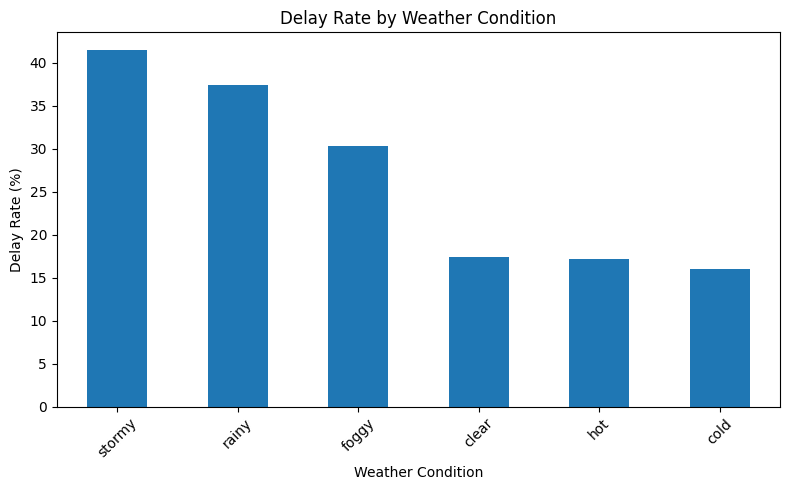

In [69]:
weather_delay = df.groupby("weather_condition")["delayed"].mean() * 100

weather_delay = weather_delay.sort_values(ascending=False)

weather_delay.plot(kind="bar", figsize=(8, 5))

plt.title("Delay Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Insight:
# Stormy and rainy weather show higher delay rates,
# while clear, hot and cold conditions have lower delay rates.

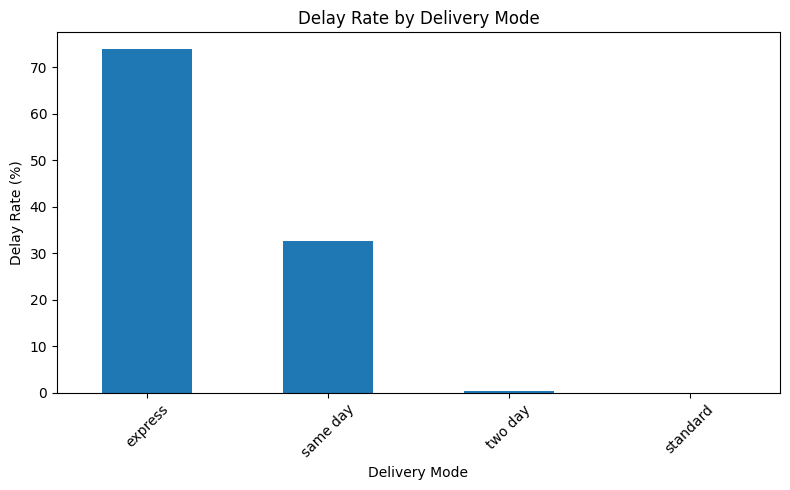

In [70]:
delivery_mode_delay = df.groupby("delivery_mode")["delayed"].mean() * 100

delivery_mode_delay = delivery_mode_delay.sort_values(ascending=False)

delivery_mode_delay.plot(kind="bar", figsize=(8, 5))

plt.title("Delay Rate by Delivery Mode")
plt.xlabel("Delivery Mode")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Insight:
# Express deliveries have the highest delay rate,
# while standard and two-day deliveries have very low delay rates.

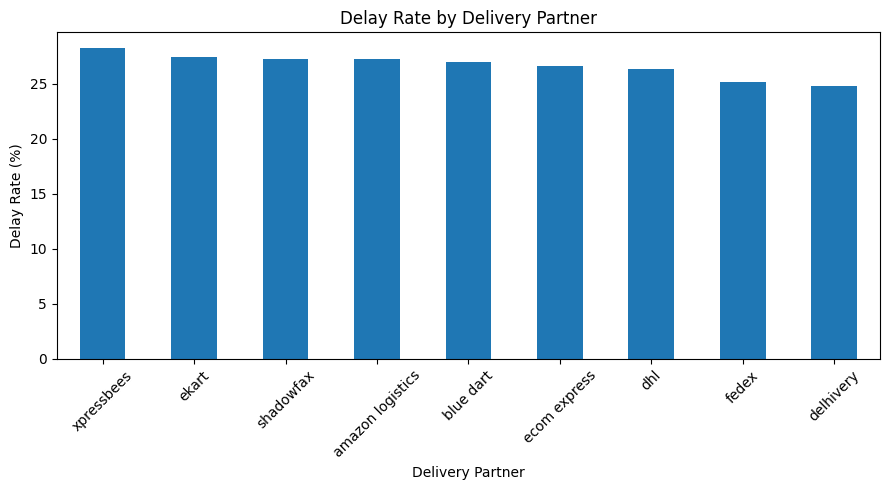

In [71]:
partner_delay = df.groupby("delivery_partner")["delayed"].mean() * 100

partner_delay = partner_delay.sort_values(ascending=False)

partner_delay.plot(kind="bar", figsize=(9, 5))

plt.title("Delay Rate by Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Insight:
# Delay rates vary across delivery partners, with XpressBees
# having the highest delay rate and Delhivery the lowest.

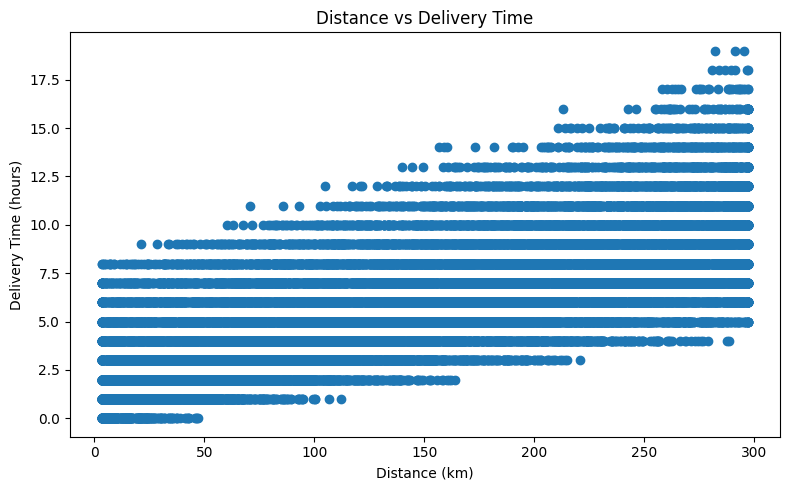

In [72]:
plt.figure(figsize=(8, 5))

plt.scatter(df["distance_km"], df["delivery_time_hours"])

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (hours)")

plt.tight_layout()
plt.show()

# Insight:
# Delivery time generally increases as the delivery distance increases.
# The correlation between distance and delivery time is positive (0.69).

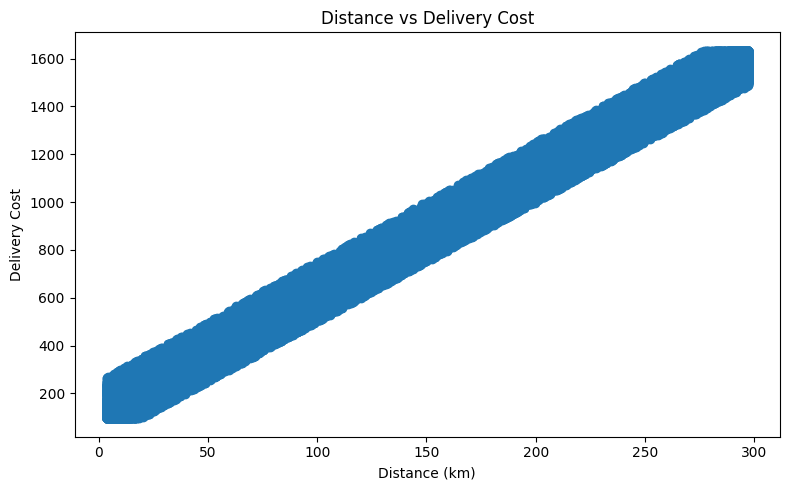

In [73]:
plt.figure(figsize=(8, 5))

plt.scatter(df["distance_km"], df["delivery_cost"])

plt.title("Distance vs Delivery Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Cost")

plt.tight_layout()
plt.show()

# Insight:
# Delivery cost increases strongly with delivery distance.
# The correlation between distance and delivery cost is very high (0.99).

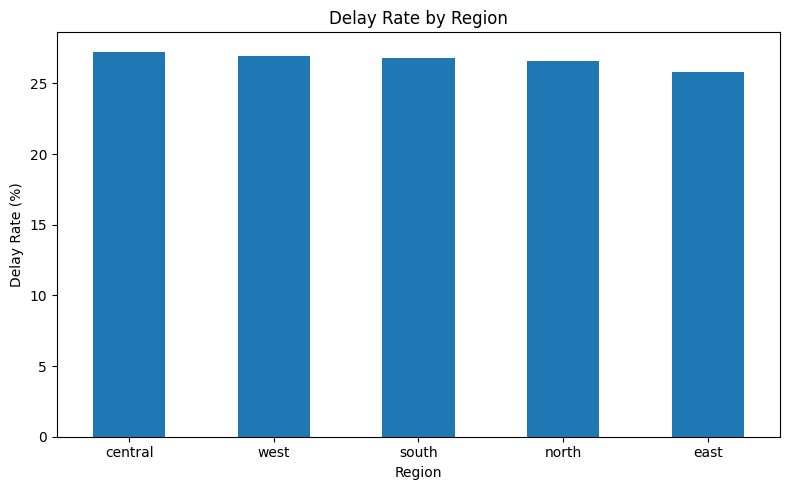

In [74]:
region_delay = df.groupby("region")["delayed"].mean() * 100

region_delay = region_delay.sort_values(ascending=False)

region_delay.plot(kind="bar", figsize=(8, 5))

plt.title("Delay Rate by Region")
plt.xlabel("Region")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Insight:
# Delay rates are similar across regions,
# suggesting that region has a limited impact on delivery delays.

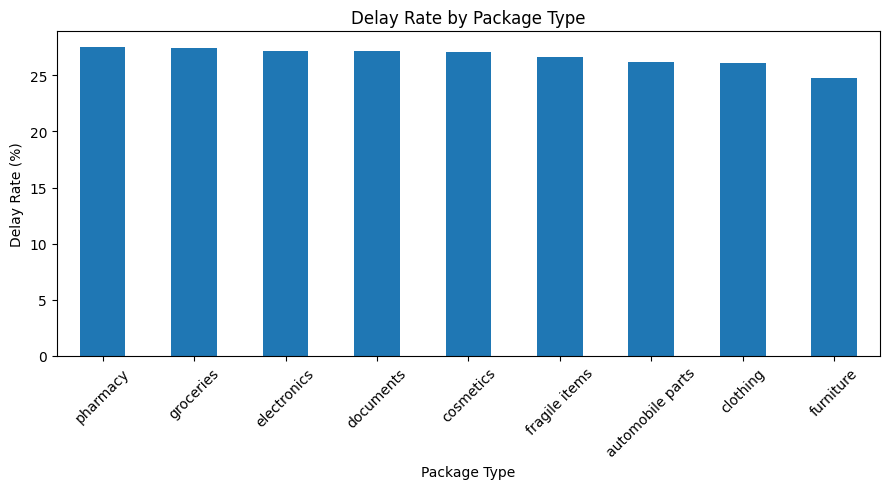

In [75]:
package_delay = df.groupby("package_type")["delayed"].mean() * 100

package_delay = package_delay.sort_values(ascending=False)

package_delay.plot(kind="bar", figsize=(9, 5))

plt.title("Delay Rate by Package Type")
plt.xlabel("Package Type")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Insight:
# Delay rates are relatively similar across package types,
# suggesting that package type has a limited impact on delivery delays.

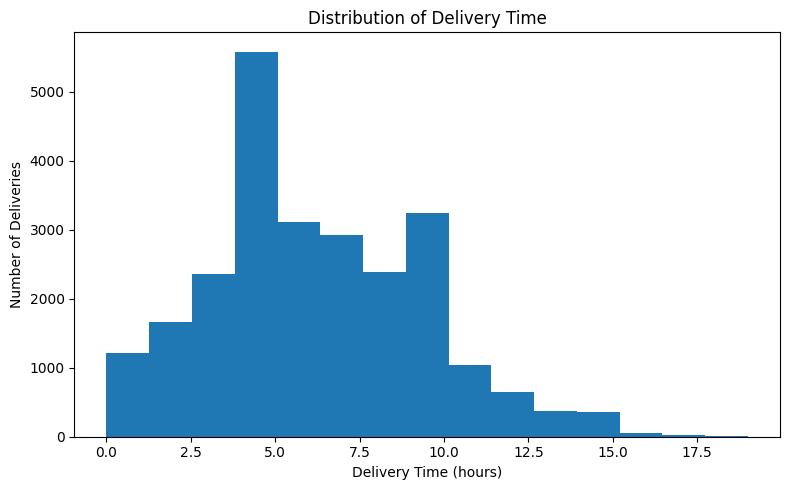

In [76]:
plt.figure(figsize=(8, 5))

plt.hist(df["delivery_time_hours"], bins=15)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Number of Deliveries")

plt.tight_layout()
plt.show()

# Insight:
# The distribution shows how delivery times are spread across
# the shipments and helps identify the common delivery time range.

## Final EDA Findings

- The overall on-time delivery rate is 73.32%, while 26.68% of deliveries are delayed.
- Stormy and rainy weather conditions have the highest delay rates, indicating that adverse weather may affect delivery performance.
- Delivery mode shows a strong difference in delay rates, with express deliveries having the highest delay rate.
- Delay rates are fairly similar across different vehicle types, regions, and package types.
- Delivery partner performance varies moderately, with some partners showing higher delay rates than others.
- Distance has a positive relationship with delivery time, with a correlation of about 0.69.
- Distance has a very strong relationship with delivery cost, with a correlation of about 0.99.
- Package weight has only a weak relationship with delivery cost in this dataset.

## Business Recommendations

1. Plan additional delivery time or backup resources for stormy and rainy weather conditions.

2. Review express delivery operations to understand why express shipments have a much higher delay rate.

3. Monitor delivery partner performance regularly and investigate partners with consistently higher delay rates.

4. Use delivery distance as an important factor when estimating delivery time and delivery cost.

5. Focus more on route planning and distance-based cost estimation rather than package weight alone.

6. Track delivery performance by weather, delivery mode, and delivery partner to identify potential areas for improvement.

## Conclusion

The analysis shows that weather conditions, delivery mode, and delivery distance are important factors related to logistics performance. Distance is strongly associated with delivery cost, while adverse weather and certain delivery modes are associated with higher delay rates. These findings can help logistics teams improve delivery planning, cost estimation, and operational monitoring.